# Airline Passengers - preparation des donnees

Chargement de la serie, normalisation 0-1, split temporel 67/33 et fenetre glissante.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import keras
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

In [2]:
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(URL)['Passengers'].values.astype('float32').reshape(-1, 1)
print('shape:', data.shape, 'min:', data.min(), 'max:', data.max())

shape: (144, 1) min: 104.0 max: 622.0


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)
print('apres MinMax -> min:', data_scaled.min(), 'max:', data_scaled.max())

apres MinMax -> min: 0.0 max: 1.0


In [4]:
train_size = int(len(data_scaled) * 0.67)
train, test = data_scaled[:train_size], data_scaled[train_size:]
print('train:', train.shape, 'test:', test.shape)

train: (96, 1) test: (48, 1)


In [5]:
def create_dataset(dataset, window_size=12):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i + window_size, 0])
        y.append(dataset[i + window_size, 0])
    X = np.array(X)
    return X.reshape(X.shape[0], window_size, 1), np.array(y)

In [6]:
WINDOW_SIZE = 12
X_train, y_train = create_dataset(train, WINDOW_SIZE)
X_test, y_test = create_dataset(test, WINDOW_SIZE)
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

X_train: (84, 12, 1) y_train: (84,)
X_test : (36, 12, 1) y_test : (36,)


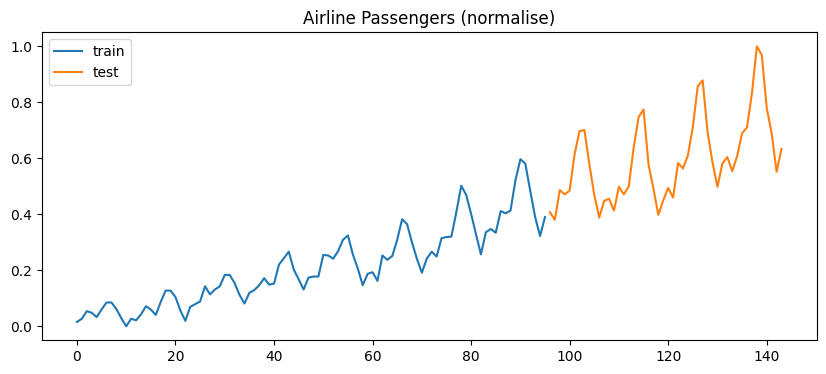

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(range(train_size), train[:, 0], label='train')
plt.plot(range(train_size, len(data_scaled)), test[:, 0], label='test')
plt.legend()
plt.title('Airline Passengers (normalise)')
plt.show()

# Modele LSTM - entrainement, prediction, RMSE

Regression : Dense(1) sans activation, loss MSE, metrique MAE. EarlyStopping sur val_loss.
batch_size=1 : beaucoup de mises a jour par epoch, la val_loss reste exploitable et l'arret se fait sur un modele bien entraine.

In [8]:
from keras import layers
from keras.callbacks import EarlyStopping
keras.utils.set_random_seed(42)

In [9]:
model = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 1)),
    layers.LSTM(64),
    layers.Dropout(0.2),
    layers.Dense(1),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=1,
    validation_split=0.1,
    callbacks=[early],
    verbose=0,
)
print('epochs effectues:', len(history.history['loss']))

epochs effectues: 41


In [11]:
train_pred = scaler.inverse_transform(model.predict(X_train, verbose=0))
test_pred = scaler.inverse_transform(model.predict(X_test, verbose=0))
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse_train = np.sqrt(np.mean((train_pred - y_train_inv) ** 2))
rmse_test = np.sqrt(np.mean((test_pred - y_test_inv) ** 2))
print(f'RMSE train : {rmse_train:.1f} passagers')
print(f'RMSE test  : {rmse_test:.1f} passagers')

RMSE train : 18.5 passagers
RMSE test  : 35.1 passagers


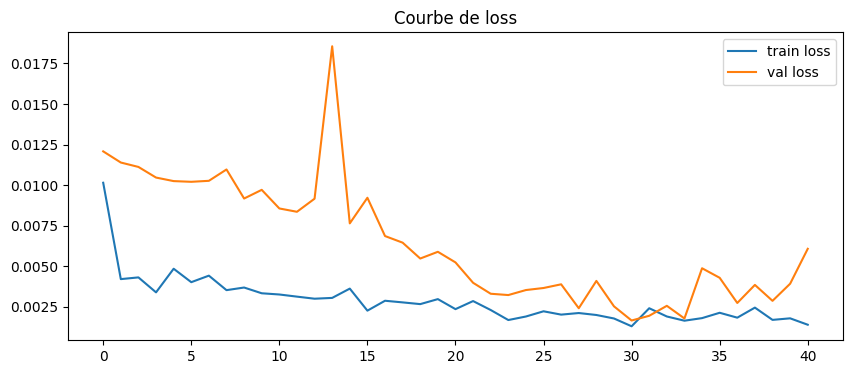

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Courbe de loss')
plt.show()

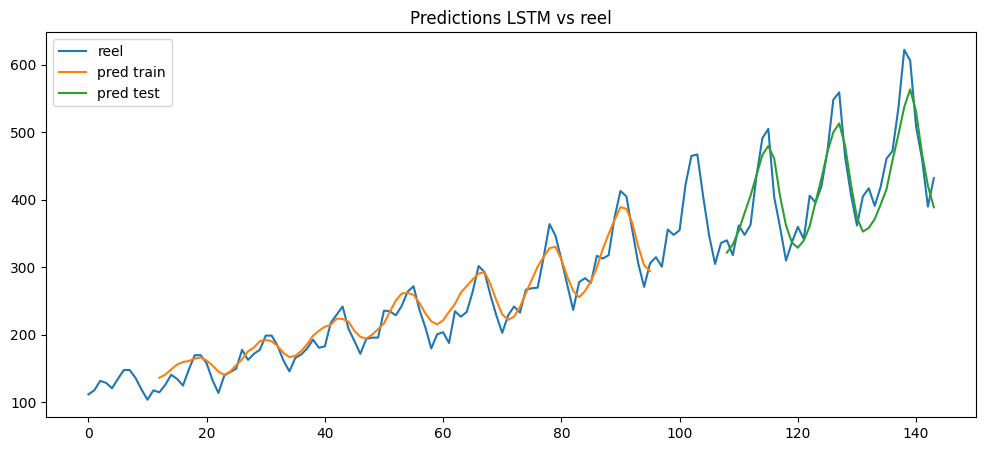

In [13]:
serie = scaler.inverse_transform(data_scaled)
plt.figure(figsize=(12, 5))
plt.plot(serie, label='reel')
plt.plot(range(WINDOW_SIZE, WINDOW_SIZE + len(train_pred)), train_pred, label='pred train')
plt.plot(range(train_size + WINDOW_SIZE, train_size + WINDOW_SIZE + len(test_pred)), test_pred, label='pred test')
plt.legend()
plt.title('Predictions LSTM vs reel')
plt.show()

In [14]:
model.save('airline_lstm.keras')
print('Modele sauvegarde : airline_lstm.keras')

Modele sauvegarde : airline_lstm.keras


# Comparaison GRU vs LSTM

Memes donnees et meme config que la phase 2 (batch_size=1, EarlyStopping) : seule l'architecture change.
Le GRU a 2 portes au lieu de 3 -> moins de parametres.

In [15]:
import time

def build_and_train(rnn_layer_class, units=64, epochs=100, label=''):
    keras.utils.set_random_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(WINDOW_SIZE, 1)),
        rnn_layer_class(units),
        layers.Dropout(0.2),
        layers.Dense(1),
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    t0 = time.time()
    h = m.fit(X_train, y_train, epochs=epochs, batch_size=1,
              validation_split=0.1, callbacks=[es], verbose=0)
    duree = time.time() - t0
    pred = scaler.inverse_transform(m.predict(X_test, verbose=0))
    rmse = float(np.sqrt(np.mean((pred - y_test_inv) ** 2)))
    n = len(h.history['loss'])
    print(f'{label}: params={m.count_params()}, epochs={n}, duree={duree:.1f}s, RMSE_test={rmse:.1f}')
    return m, h, duree, rmse, pred

In [16]:
lstm_model, lstm_hist, lstm_time, lstm_rmse, lstm_pred = build_and_train(layers.LSTM, units=64, epochs=100, label='LSTM')
gru_model, gru_hist, gru_time, gru_rmse, gru_pred = build_and_train(layers.GRU, units=64, epochs=100, label='GRU')

LSTM: params=16961, epochs=41, duree=17.0s, RMSE_test=35.1


GRU: params=12929, epochs=98, duree=51.0s, RMSE_test=33.4


In [17]:
def ligne(model, hist, duree, rmse):
    ep = len(hist.history['loss'])
    return [model.count_params(), ep, round(duree, 1), round(duree / ep, 3),
            round(hist.history['val_loss'][-1], 4), round(rmse, 1)]

compare = pd.DataFrame(
    {'LSTM': ligne(lstm_model, lstm_hist, lstm_time, lstm_rmse),
     'GRU': ligne(gru_model, gru_hist, gru_time, gru_rmse)},
    index=['Parametres', 'Epochs', 'Temps total (s)', 'Temps/epoch (s)', 'Val loss finale', 'RMSE test'],
)
print(compare)

                       LSTM         GRU
Parametres       16961.0000  12929.0000
Epochs              41.0000     98.0000
Temps total (s)     17.0000     51.0000
Temps/epoch (s)      0.4140      0.5210
Val loss finale      0.0061      0.0031
RMSE test           35.1000     33.4000


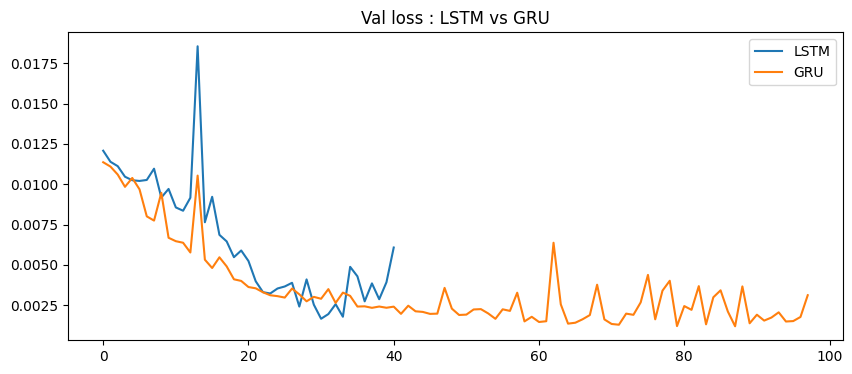

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(lstm_hist.history['val_loss'], label='LSTM')
plt.plot(gru_hist.history['val_loss'], label='GRU')
plt.legend()
plt.title('Val loss : LSTM vs GRU')
plt.show()

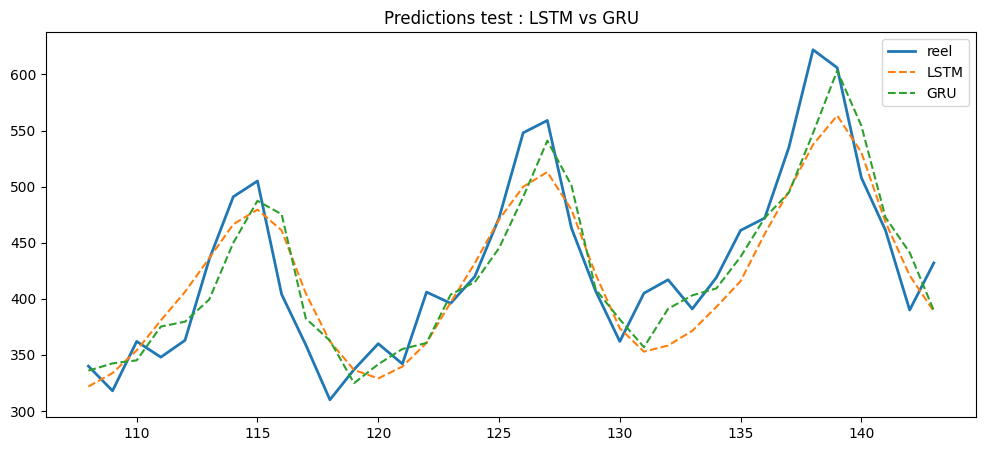

In [19]:
idx = range(train_size + WINDOW_SIZE, train_size + WINDOW_SIZE + len(y_test_inv))
plt.figure(figsize=(12, 5))
plt.plot(idx, y_test_inv, label='reel', linewidth=2)
plt.plot(idx, lstm_pred, '--', label='LSTM')
plt.plot(idx, gru_pred, '--', label='GRU')
plt.legend()
plt.title('Predictions test : LSTM vs GRU')
plt.show()